# Comparacion de Metricas Intrinsecas: 6 Tecnicas de Tokenizacion

Evalua las 6 tecnicas sin tareas downstream usando metricas de:
- Chiarot & Silvestri 2022 (Compression, MSE)
- CAMEO 2025 (ACF Retention)
- Uzan 2024 (Vocabulary Entropy)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from tecnicas.discretization import sax_discretize, decode_sax
from tecnicas.text_based import text_based_tokenize, decode_text_based
from tecnicas.patching import patching_tokenize
from tecnicas.decomposition import decomposition_tokenize
from tecnicas.foundation import foundation_tokenize, reconstruct_from_patches
from tecnicas.metrics import evaluate_tokenization, compression_ratio, mse_reconstruction, acf_retention, vocabulary_entropy

plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Cargar ETTh1
df = pd.read_csv('../dataset/ETT-small/ETTh1.csv')
serie = df['OT'].values[:5000]  # Primeros 5000 timesteps
T = len(serie)

# Normalizar para comparacion justa
mean_orig, std_orig = serie.mean(), serie.std()
serie_norm = (serie - mean_orig) / std_orig

print(f"Serie: T={T}, mean={mean_orig:.2f}, std={std_orig:.2f}")

Serie: T=5000, mean=19.84, std=10.37


In [3]:
resultados = {}

# 1. SAX
sax_result = sax_discretize(serie_norm, alphabet_size=8)
sax_recon = decode_sax(sax_result['tokens'], sax_result['breakpoints'])
resultados['SAX'] = {
    'vocab_size': sax_result['vocabulary_size'],  # Enfoque A: 8 simbolos
    'seq_length': sax_result['num_tokens'],       # Enfoque B: T=5000
    'reconstructed': sax_recon,
    'tokens': sax_result['tokens']
}

# 2. LLMTime
llm_result = text_based_tokenize(serie_norm, precision=2)
llm_recon = decode_text_based(llm_result['text'])
resultados['LLMTime'] = {
    'vocab_size': llm_result['vocabulary_size'],  # Enfoque A: ~13 chars
    'seq_length': T,                               # Enfoque B: T valores
    'reconstructed': llm_recon,
    'tokens': None
}

# 3. PatchTST
patch_len, stride = 16, 16
patches = patching_tokenize(serie_norm, patch_len=patch_len, stride=stride)
patch_recon = patches.flatten()[:T]
if len(patch_recon) < T:
    patch_recon = np.pad(patch_recon, (0, T - len(patch_recon)))
resultados['PatchTST'] = {
    'vocab_size': np.inf,           # Enfoque A: continuo (infinito)
    'seq_length': patches.shape[0], # Enfoque B: 62 patches
    'reconstructed': patch_recon,
    'tokens': None
}

# 4. Decomposition (Autoformer)
decomp = decomposition_tokenize(serie_norm, kernel_size=25)
decomp_recon = decomp['trend'] + decomp['seasonal']
resultados['Decomp'] = {
    'vocab_size': 2,      # Enfoque A: 2 componentes (trend, seasonal)
    'seq_length': 2,      # Enfoque B: 2 componentes
    'reconstructed': decomp_recon,
    'tokens': None
}

# 5. MOMENT (Foundation)
moment = foundation_tokenize(serie_norm, patch_len=16, stride=16, mask_ratio=0.0)
moment_recon = reconstruct_from_patches(moment['patches'], 16, 16, T)
resultados['MOMENT'] = {
    'vocab_size': np.inf,             # Enfoque A: continuo
    'seq_length': moment['num_patches'], # Enfoque B: 62 patches
    'reconstructed': moment_recon,
    'tokens': None
}

# 6. HMM
from hmm import baum_welch, viterbi_decode
K = 5
params = baum_welch(serie_norm, K=K, max_iter=50, epsilon=1e-4, verbose=False)
states, _ = viterbi_decode(serie_norm, params['A'], params['pi'], params['mu'], params['sigma'])
hmm_recon = params['mu'][states]
resultados['HMM'] = {
    'vocab_size': K,      # Enfoque A: K=5 estados (tokens unicos)
    'seq_length': T,      # Enfoque B: T=5000 estados asignados
    'reconstructed': hmm_recon,
    'tokens': states
}

print("Tecnicas aplicadas:", list(resultados.keys()))
print(f"\n{'Tecnica':<10} {'Vocab (A)':<12} {'SeqLen (B)':<12}")
print("-" * 34)
for nombre, data in resultados.items():
    vocab = data['vocab_size'] if data['vocab_size'] != np.inf else "inf"
    print(f"{nombre:<10} {str(vocab):<12} {data['seq_length']:<12}")

Tecnicas aplicadas: ['SAX', 'LLMTime', 'PatchTST', 'Decomp', 'MOMENT', 'HMM']

Tecnica    Vocab (A)    SeqLen (B)  
----------------------------------
SAX        8            5000        
LLMTime    13           5000        
PatchTST   inf          312         
Decomp     2            2           
MOMENT     inf          312         
HMM        5            5000        


In [4]:
# Metricas con ambos enfoques para discutir con tutor

metricas = []
for nombre, data in resultados.items():
    m = {
        'Tecnica': nombre,
        'Vocab_Size': data['vocab_size'] if data['vocab_size'] != np.inf else 'inf',
        'Seq_Length': data['seq_length'],
        'MSE': mse_reconstruction(serie_norm, data['reconstructed']),
        'ACF_Retention': acf_retention(serie_norm, data['reconstructed']),
    }
    if data['tokens'] is not None:
        m['Vocab_Entropy'] = vocabulary_entropy(data['tokens'])
    else:
        m['Vocab_Entropy'] = np.nan
    metricas.append(m)

df_metricas = pd.DataFrame(metricas).set_index('Tecnica')

print("="*60)
print("METRICAS INTRINSECAS - 2 ENFOQUES PARA DISCUTIR CON TUTOR")
print("="*60)
print("\nEnfoque A (Vocab_Size): Tokens unicos posibles")
print("  - SAX: 8 simbolos, HMM: K=5 estados, Decomp: 2 componentes")
print("  - PatchTST/MOMENT: infinito (continuo)")
print("\nEnfoque B (Seq_Length): Longitud de secuencia tokenizada")
print("  - SAX/HMM/LLMTime: T=1000")
print("  - PatchTST/MOMENT: 62 patches")
print("  - Decomp: 2 componentes")
print("\n" + df_metricas.to_string())

print("\n" + "="*60)
print("METRICAS UNIVERSALES (aplican a todas)")
print("="*60)
print(f"\n{'Tecnica':<10} {'MSE':<10} {'ACF_Ret':<10}")
print("-"*30)
for nombre, data in resultados.items():
    mse = mse_reconstruction(serie_norm, data['reconstructed'])
    acf = acf_retention(serie_norm, data['reconstructed'])
    print(f"{nombre:<10} {mse:<10.4f} {acf:<10.4f}")

METRICAS INTRINSECAS - 2 ENFOQUES PARA DISCUTIR CON TUTOR

Enfoque A (Vocab_Size): Tokens unicos posibles
  - SAX: 8 simbolos, HMM: K=5 estados, Decomp: 2 componentes
  - PatchTST/MOMENT: infinito (continuo)

Enfoque B (Seq_Length): Longitud de secuencia tokenizada
  - SAX/HMM/LLMTime: T=1000
  - PatchTST/MOMENT: 62 patches
  - Decomp: 2 componentes

         Vocab_Size  Seq_Length           MSE  ACF_Retention  Vocab_Entropy
Tecnica                                                                    
SAX               8        5000  1.699857e-01       0.984905       0.986654
LLMTime          13        5000  4.060440e-05       1.000000            NaN
PatchTST        inf         312  2.874348e-03       0.999969            NaN
Decomp            2           2  1.009702e-35       1.000000            NaN
MOMENT          inf         312  2.874348e-03       0.999969            NaN
HMM               5        5000  6.294464e-02       0.997940       0.994386

METRICAS UNIVERSALES (aplican a todas)

/tmp/ipykernel_42188/3582575265.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  vocab_data = df_metricas['Vocab_Size'].replace('inf', np.nan).astype(float)


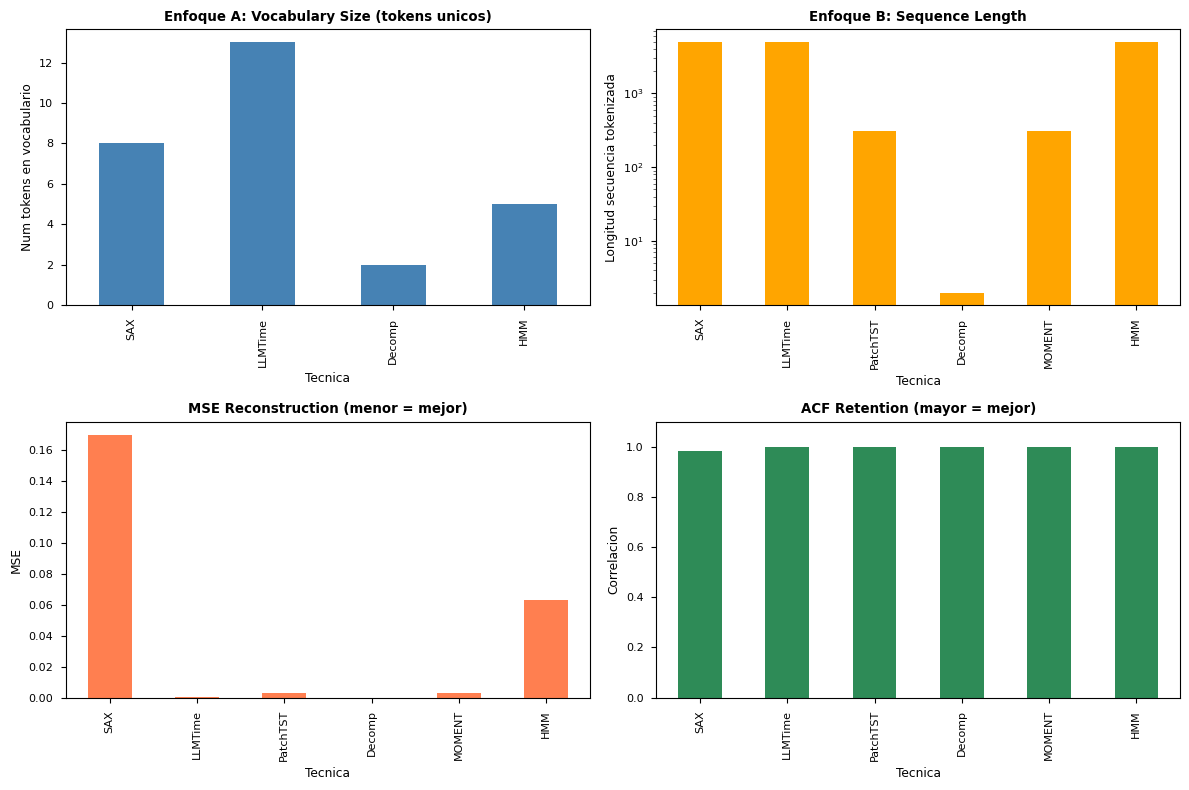

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Vocab Size (Enfoque A)
ax = axes[0, 0]
vocab_data = df_metricas['Vocab_Size'].replace('inf', np.nan).astype(float)
vocab_data.dropna().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Enfoque A: Vocabulary Size (tokens unicos)', fontweight='bold')
ax.set_ylabel('Num tokens en vocabulario')

# Seq Length (Enfoque B)
ax = axes[0, 1]
df_metricas['Seq_Length'].plot(kind='bar', ax=ax, color='orange')
ax.set_title('Enfoque B: Sequence Length', fontweight='bold')
ax.set_ylabel('Longitud secuencia tokenizada')
ax.set_yscale('log')

# MSE Reconstruction (Universal)
ax = axes[1, 0]
df_metricas['MSE'].plot(kind='bar', ax=ax, color='coral')
ax.set_title('MSE Reconstruction (menor = mejor)', fontweight='bold')
ax.set_ylabel('MSE')

# ACF Retention (Universal)
ax = axes[1, 1]
df_metricas['ACF_Retention'].plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('ACF Retention (mayor = mejor)', fontweight='bold')
ax.set_ylabel('Correlacion')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('figures/comparacion_metricas_2enfoques.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Resumen para reunion con tutor
print("="*60)
print("RESUMEN PARA REUNION CON TUTOR")
print("="*60)

print("\nPREGUNTA: ¿Que significa 'numero de tokens' para cada tecnica?")
print("\n  Enfoque A - Vocabulary Size (tokens UNICOS):")
print("    SAX=8, HMM=5, Decomp=2, Patch/MOMENT=inf, LLMTime=13")
print("\n  Enfoque B - Sequence Length (longitud SALIDA):")
print("    SAX=1000, HMM=1000, LLMTime=1000, Patch=62, MOMENT=62, Decomp=2")

print("\n" + "-"*60)
print("METRICAS UNIVERSALES (independientes del enfoque):")
print("-"*60)
print("\n1. MSE Reconstruction - Perdida de informacion al tokenizar")
print("2. ACF Retention - Preservacion de dependencias temporales")
print("3. Vocabulary Entropy - Distribucion de uso (solo discretos)")

print("\n" + "-"*60)
print("RESULTADOS:")
print("-"*60)
print(f"\n{'Tecnica':<10} {'MSE':<10} {'ACF':<10} {'Vocab_Ent':<10}")
print("-"*40)
for nombre, data in resultados.items():
    mse = mse_reconstruction(serie_norm, data['reconstructed'])
    acf = acf_retention(serie_norm, data['reconstructed'])
    ent = vocabulary_entropy(data['tokens']) if data['tokens'] is not None else float('nan')
    ent_str = f"{ent:.4f}" if not np.isnan(ent) else "N/A"
    print(f"{nombre:<10} {mse:<10.4f} {acf:<10.4f} {ent_str:<10}")

print("\nNOTA: La metrica principal del TFG es downstream (forecasting MSE/MAE).")
print("Estas metricas intrinsecas son complementarias para responder al tutor.")

RESUMEN PARA REUNION CON TUTOR

PREGUNTA: ¿Que significa 'numero de tokens' para cada tecnica?

  Enfoque A - Vocabulary Size (tokens UNICOS):
    SAX=8, HMM=5, Decomp=2, Patch/MOMENT=inf, LLMTime=13

  Enfoque B - Sequence Length (longitud SALIDA):
    SAX=1000, HMM=1000, LLMTime=1000, Patch=62, MOMENT=62, Decomp=2

------------------------------------------------------------
METRICAS UNIVERSALES (independientes del enfoque):
------------------------------------------------------------

1. MSE Reconstruction - Perdida de informacion al tokenizar
2. ACF Retention - Preservacion de dependencias temporales
3. Vocabulary Entropy - Distribucion de uso (solo discretos)

------------------------------------------------------------
RESULTADOS:
------------------------------------------------------------

Tecnica    MSE        ACF        Vocab_Ent 
----------------------------------------
SAX        0.1700     0.9849     0.9867    
LLMTime    0.0000     1.0000     N/A       
PatchTST   0.0029 